In [1]:
import pandas as pd
import numpy as np
from hdr_adjustments import contrast_enhancement
import matplotlib.pyplot as plt
from skimage import io
from matplotlib.colors import ListedColormap, BoundaryNorm
from preprocess_point_cloud import map_angle_to_pixel
from typing import Union, List
from pathlib import Path
from plot_tools import smart_image_pie_chart, get_image_histogram, display_unwrapped_single_band_images, display_unwrapped_rgb_image, display_single_band_img_wt_discrete_values
from norm_to_hsv import attach_normal_color_to_df

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


# Convert the bin file to a pcd file.

In [2]:
# from preprocess_point_cloud import convert_SemanticKitti_bin_to_pcd

# for i in range(4220, 4230):
#     name_base = f'{i:06d}'
#     filename = Path(f'/home/fzhcis/mylab/mmdetection3d/data/semantickitti/sequences/00/velodyne/{name_base}.bin')
#     output_dir = Path('/home/fzhcis/mylab/gdrive/projects_with_Jan/point_cloud_segmentation/tests/semantickitti-seq00')
#     pcd_filename = output_dir / f'{name_base}.pcd'
#     convert_SemanticKitti_bin_to_pcd(filename, pcd_filename)



In [3]:
# filename = pcd_filename
# saveflag = False


In [4]:
# Ignore warnings
pd.options.mode.chained_assignment = None  # Disable the warning

## Initialize Input Paths

In [5]:
saveflag = True

filename = Path('/home/fzhcis/mylab/gdrive/projects_with_Jan/point_cloud_segmentation/tests/semantickitti-seq00/outputs/004222_filtered_normaled_curvature_0.20_roughness_0.20.txt')
output_dir = Path("/home/fzhcis/mylab/gdrive/projects_with_Jan/point_cloud_segmentation/tests/semantickitti-seq00/outputs")

In [6]:
# AZIMUTH_NORM_SCALE = 360
# ZENITH_NORM_SCALE = 135
# # Since degree resolution=0.25: 360/0.25=1440
# CANVAS_WIDTH = 1440 
# CANVAS_HEIGHT = 540

In [7]:
CANVAS_WIDTH = 4500 
CANVAS_HEIGHT = 64

## Preprocess the Point Cloud data
- read the data as a pandas dataframe
- Clean it
  - Filter with first return and non-extreme intensity values
- prepare x_pix and y_pix columns for grouping

## Prepare the functions for displaying images.

### Observe the density map and histograms

In [8]:
def load_and_preprocess_point_cloud(filename: Union[str, Path]) -> pd.DataFrame:
    """
    Load the point cloud data and preprocess it by:
    1. Attach the pixel values for azimuth and elevation
    2. Attach the HSV color values for the normal
    3. Reverse the range values and z values

    Args:
        filename: str or Path: The path to the point cloud data

    Returns:
        pd.DataFrame: The preprocessed point cloud data
    """

    df_filtered = pd.read_csv(filename, sep=',')
    azimuth, elevation = df_filtered['azimuth'], df_filtered['elevation']
    x_pix, y_pix = map_angle_to_pixel(azimuth, elevation)
    df_filtered['x_pix'] = x_pix
    df_filtered['y_pix'] = y_pix

    # Grab HSV color from the normal and attach the color to the dataframe
    df_filtered_ncolored = attach_normal_color_to_df(df_filtered)

    # reverse the range values and z values
    # df_filtered_ncolored['rangemeter'] = df_filtered_ncolored['rangemeter'].max() - df_filtered_ncolored['rangemeter']  

    # # shift the z values to start from 0
    # df_filtered_ncolored['Z'] = df_filtered_ncolored['Z'] - df_filtered_ncolored['Z'].min()

    # Normalize columns: Intensity, rangemeter, curvature and roughness, to (0, 1)
    for col_name in ['Intensity', 'rangemeter']:
        df_filtered_ncolored[col_name] = (df_filtered_ncolored[col_name] - df_filtered_ncolored[col_name].min()) / (df_filtered_ncolored[col_name].max() - df_filtered_ncolored[col_name].min())

    # Check if there are NaN values or negative values in the columns of interest
    for col_name in ['Intensity', 'azimuth', 'zenith', 'rangemeter']:
            assert df_filtered_ncolored[col_name].isnull().sum() == 0, f"Column {col_name} has NaN values"
            assert (df_filtered_ncolored[col_name] < 0).sum() == 0, f"Column {col_name} has negative values"

    return df_filtered_ncolored

In [9]:
def unwrap_point_cloud_to_2d_images(filename: str) -> tuple[pd.DataFrame, tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]]:
    """
    Unwrap the point cloud to 2D images with x being azimuth angle, y being zenith angle, and pixel value with different kinds of scalar fields.
    Including density, intensity, range, and range-xy images.

    Parameters:
    filename (str): The path to the point cloud data file in CSV format.
    saveflag (bool): If True, save the images to the output_dir directory. Default is True.

    Returns:
    df_filtered (pd.DataFrame): A DataFrame containing the filtered and processed point cloud data with additional columns for pixel coordinates.
    tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]: A tuple containing the density image, adjusted intensity image, adjusted range image, and adjusted range-xy image.
    """
    ## Load and Preprocess the point cloud data
    df_filtered_ncolored = load_and_preprocess_point_cloud(filename)
    grouped = df_filtered_ncolored.groupby(['y_pix', 'x_pix'], observed=False)

    ## Compute intensity and range per pixel. 
    ## Since less than 0.1% of the pixels contain more than one point, it doesn't matter if we use mean or max.
    group_intensity = grouped['Intensity'].max()
    group_range = grouped['rangemeter'].max()
    pts_per_pixel = grouped.size()
    curvature_per_pixel = grouped['curvature'].max()
    roughness_per_pixel = grouped['roughness'].max()
    

    ## Map the computed values to the image arrays
    ## Create empty image canvases with proper resolution
    intensity_image = np.zeros((CANVAS_HEIGHT, CANVAS_WIDTH), dtype=np.float32)
    range_image = np.zeros((CANVAS_HEIGHT, CANVAS_WIDTH), dtype=np.float32)
    density_image = np.zeros((CANVAS_HEIGHT, CANVAS_WIDTH), dtype=np.float32)
    curvature_image = np.zeros((CANVAS_HEIGHT, CANVAS_WIDTH), dtype=np.float32)
    roughness_image = np.zeros((CANVAS_HEIGHT, CANVAS_WIDTH), dtype=np.float32)
    
    pxpy_indices = np.array(group_intensity.index.tolist())
    intensity_image[pxpy_indices[:, 0], pxpy_indices[:, 1]] = group_intensity.values
    range_image[pxpy_indices[:, 0], pxpy_indices[:, 1]] = group_range.values
    density_image[pxpy_indices[:, 0], pxpy_indices[:, 1]] = pts_per_pixel.values
    curvature_image[pxpy_indices[:, 0], pxpy_indices[:, 1]] = curvature_per_pixel.values
    roughness_image[pxpy_indices[:, 0], pxpy_indices[:, 1]] = roughness_per_pixel.values


    # Step 6: Apply HDR adjustment to intensity and range images
    intensity_image_adjusted = contrast_enhancement(intensity_image, stretch_percent=4)
    range_image_adjusted = contrast_enhancement(range_image)
    curvature_image_adjusted = contrast_enhancement(curvature_image)
    roughness_image_adjusted = contrast_enhancement(roughness_image)

    image_names = ['Density Map', 
                    'Intensity Map (adjusted)', 
                    'Range Map (adjusted)', 
                    'Curvature Map (adjusted)',
                    'Roughness Map (adjusted)',
                    'Intensity Map (raw)', 
                    'Range Map (raw)', 
                    'Curvature Map (raw)',
                    'Roughness Map (raw)',
                    ]
    
    

    output_images = (density_image, 
                     intensity_image_adjusted, 
                     range_image_adjusted, 
                     curvature_image_adjusted,
                     roughness_image_adjusted,
                     intensity_image, 
                     range_image, 
                     curvature_image,
                     roughness_image,
                     )
    
    output_images_dict = {image_name: image for image_name, image in zip(image_names, output_images)}
   
    return df_filtered_ncolored, output_images_dict


In [10]:
def unwrap_pc_normals_to_rgb_image(df_filtered_ncolored: pd.DataFrame) -> np.ndarray:
    """
    Unwrap the point cloud to 2D images with x being azimuth angle, y being zenith angle, and pixel values
    colorized by the normal vectors.

    Parameters:
    
    """
    grouped = df_filtered_ncolored.groupby(['y_pix', 'x_pix'], observed=False)

    r_per_pixel = grouped['n_r'].mean()
    g_per_pixel = grouped['n_g'].mean()
    b_per_pixel = grouped['n_b'].mean()


    ## Map the computed values to the image arrays
    ## Create empty image canvases with proper resolution
    r_image = np.zeros((CANVAS_HEIGHT, CANVAS_WIDTH), dtype=np.float32)
    g_image = np.zeros((CANVAS_HEIGHT, CANVAS_WIDTH), dtype=np.float32)
    b_image = np.zeros((CANVAS_HEIGHT, CANVAS_WIDTH), dtype=np.float32)
    
    pxpy_indices = np.array(r_per_pixel.index.tolist())
    r_image[pxpy_indices[:, 0], pxpy_indices[:, 1]] = r_per_pixel.values
    g_image[pxpy_indices[:, 0], pxpy_indices[:, 1]] = g_per_pixel.values
    b_image[pxpy_indices[:, 0], pxpy_indices[:, 1]] = b_per_pixel.values

    # Stack the single channel images to create an RGB image
    rgb_image = np.stack((r_image, g_image, b_image), axis=-1) # Shape: (540, 1440, 3)
   
    return rgb_image

## Run the above process
- display density map and density histogram
- display Intensity Map, Range Map, and Range-XY Map

Image value range before adjustment: [0.0, 1.0]
Image rescaled to [0, 1].
Stretching image by 4 percent.
CLAHE applied.
Image value range before adjustment: [0.0, 1.0]
Image rescaled to [0, 1].
Stretching image by 2 percent.
CLAHE applied.
Image value range before adjustment: [-6.293338117302483e-08, 0.3029913008213043]
Image rescaled to [0, 1].
Stretching image by 2 percent.
CLAHE applied.
Image value range before adjustment: [0.0, 0.06746642291545868]
Image rescaled to [0, 1].
Stretching image by 2 percent.
CLAHE applied.


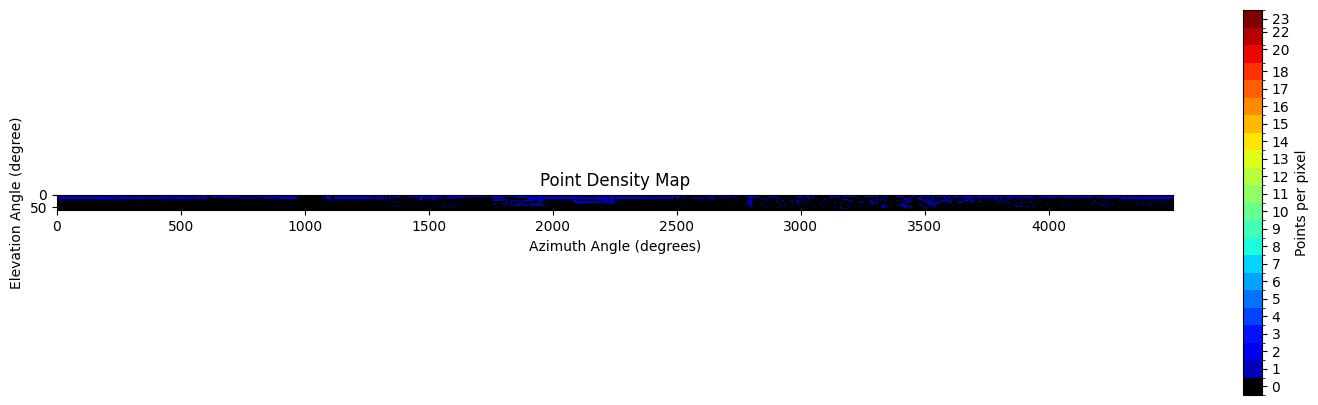

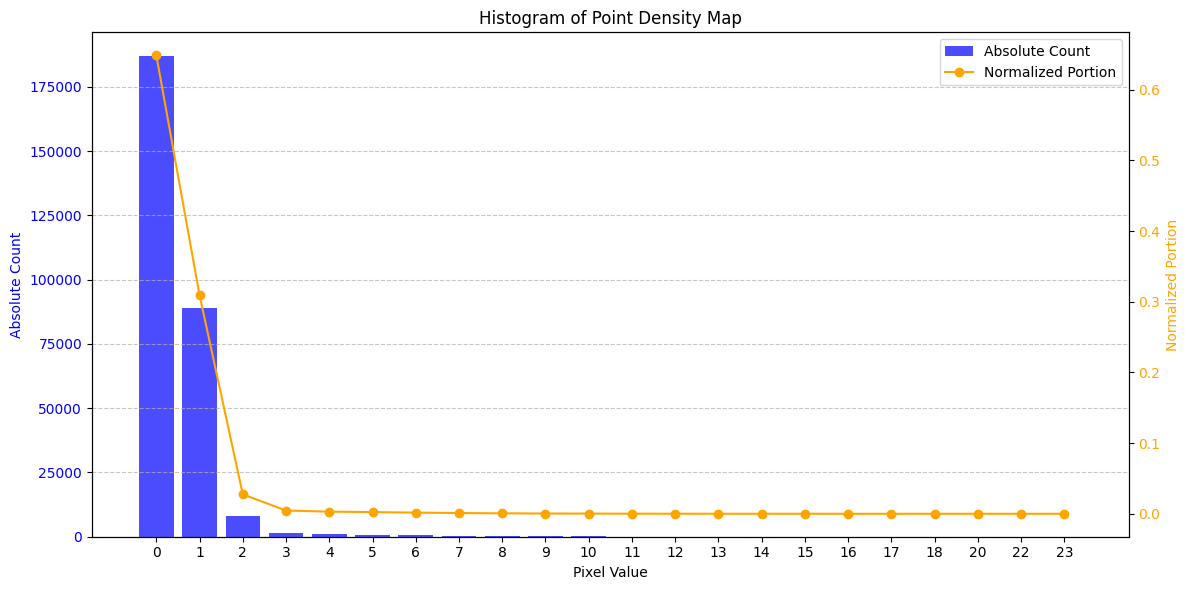

Histogram:
Values: [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 20. 22. 23.]
Counts: [186807  89044   7928   1330    879    698    485    309    194    107
     88     38     34     21     11     13      4      3      4      1
      1      1]
Normalized Counts: [0.649 0.309 0.028 0.005 0.003 0.002 0.002 0.001 0.001 0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.   ]


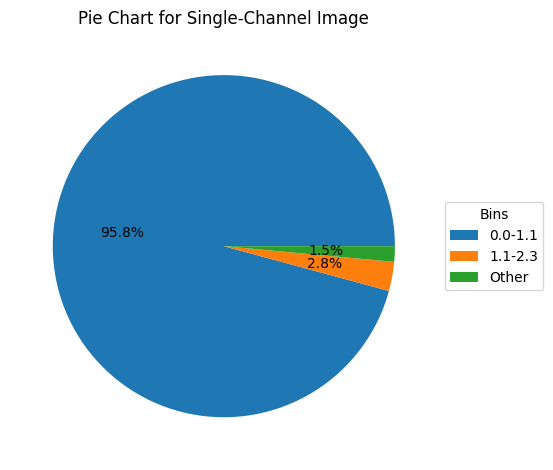

In [11]:
df_filtered, output_images_dict = unwrap_point_cloud_to_2d_images(filename)
density_image = output_images_dict['Density Map']
display_single_band_img_wt_discrete_values(density_image, title='Point Density Map', output_dir=output_dir, saveflag=False)




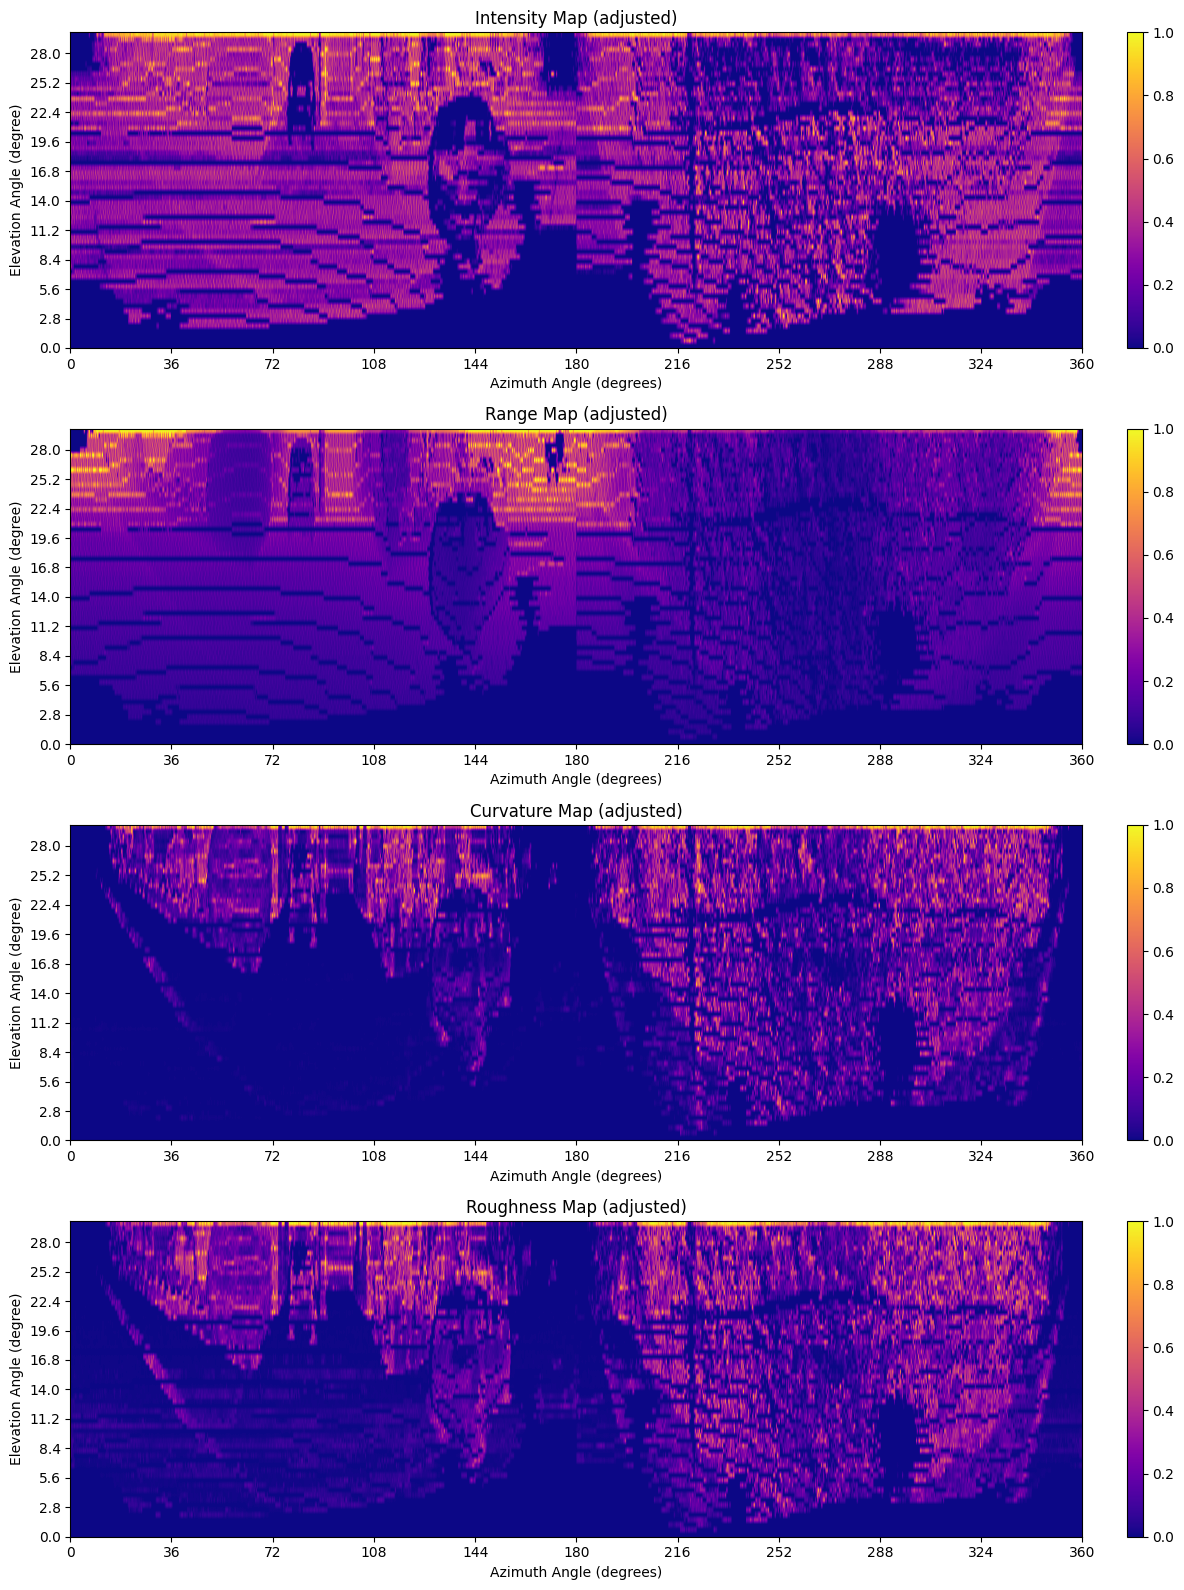

Images saved to /home/fzhcis/mylab/gdrive/projects_with_Jan/point_cloud_segmentation/tests/semantickitti-seq00/outputs directory


In [12]:

# Step 7: Display and save the adjusted intensity and range images
titles = ['Intensity Map (adjusted)', 'Range Map (adjusted)', 'Curvature Map (adjusted)', 'Roughness Map (adjusted)']
display_images = [output_images_dict[title] for title in titles]
display_unwrapped_single_band_images(display_images, 
                                    titles=titles,
                                    output_dir=output_dir,
                                    saveflag=saveflag)



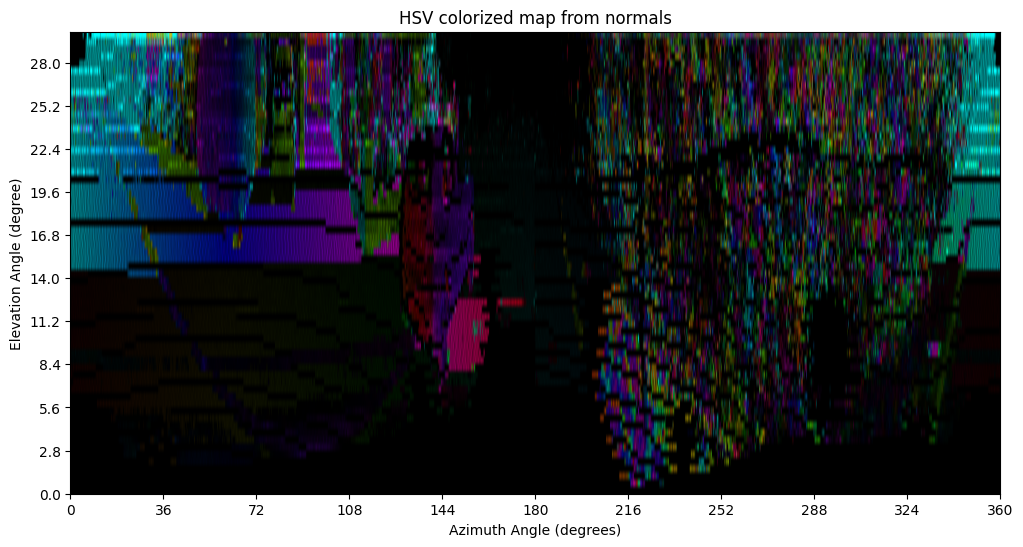

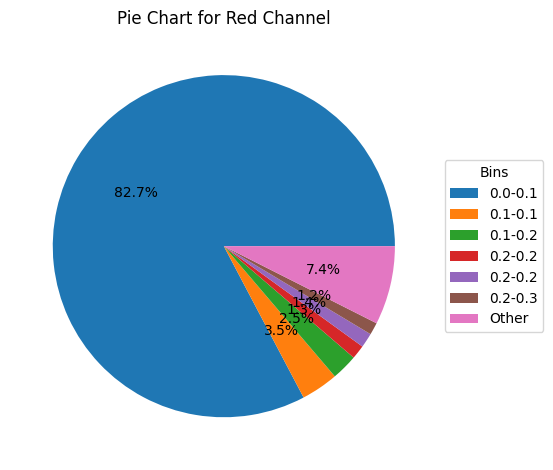

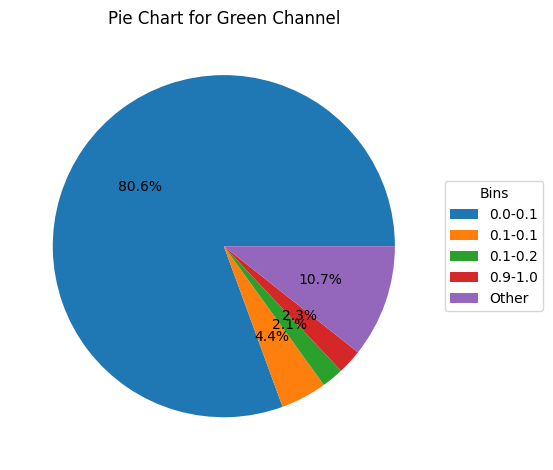

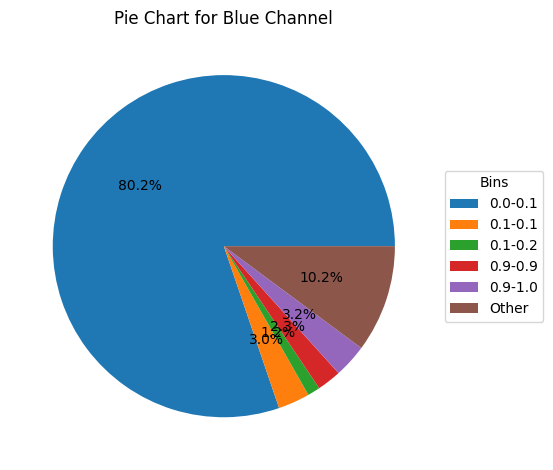

In [13]:
# Display the normals colorized RGB image.
normals_rgb_image = unwrap_pc_normals_to_rgb_image(df_filtered)
display_unwrapped_rgb_image(normals_rgb_image, 
                            figure_title='HSV colorized map from normals', 
                            saveflag=saveflag, 
                            output_dir=output_dir)

In [14]:
# for hist_image, title in zip(output_images, titles):
#     get_image_histogram(image_data=hist_image, title=title, saveflag=False, output_dir=output_dir)

## Combine Unwrapped images to an psudo-RGB image

In [15]:
def normalize_and_stack_images(image_list: List[np.array], method="global"):
    """
    Normalize a list of image channels either globally after stacking or per-channel before stacking.

    Parameters:
        image_list (list of np.ndarray): List of 2D arrays representing image channels (e.g., intensity, range).
        method (str): Normalization method, either "global" for global normalization after stacking
                      or "per_channel" for per-channel normalization before stacking.
                      

    Returns:
        np.ndarray: Normalized and stacked 3D array with shape (H, W, C).
    """
    if method not in ["global", "per_channel"]:
        raise ValueError("Invalid method. Choose 'global' or 'per_channel'.")

    if method == "per_channel":
        # Normalize each channel independently
        for i in range(len(image_list)):
            img_mean = image_list[i].mean()
            img_std = image_list[i].std()
            img_norm = (image_list[i] - img_mean) / (img_std + 1e-8)  # Avoid division by zero
            img_min = img_norm.min()
            img_max = img_norm.max()
            image_list[i] = (img_norm - img_min) / (img_max - img_min)

        # Stack the normalized channels
        stacked_image = np.stack(image_list, axis=-1)

    elif method == "global":
        # Normalize each channel first (zero mean, unit variance)
        for i in range(len(image_list)):
            img_mean = image_list[i].mean()
            img_std = image_list[i].std()
            image_list[i] = (image_list[i] - img_mean) / (img_std + 1e-8)

        # Stack the channels
        stacked_image = np.stack(image_list, axis=-1)

        # Perform global rescaling to (0, 1)
        stack_min = stacked_image.min()
        stack_max = stacked_image.max()
        stacked_image = (stacked_image - stack_min) / (stack_max - stack_min + 1e-8)

    return stacked_image

In [16]:
def create_pseudo_rgb_image(intensity_image: np.ndarray, 
                            range_image: np.ndarray, 
                            third_channel_img: np.ndarray, 
                            figure_title: str = '',
                            saveflag:bool=False) -> np.ndarray:
    """
    Combine intensity, range, and density images into a pseudo-RGB image.

    Parameters:
    -----------
    intensity_image : np.ndarray
        The adjusted intensity image.
    range_image : np.ndarray
        The adjusted range image.
    third_channel_img : np.ndarray
        The third channel image, can be roughness or curvature.

    Returns:
    --------
    np.ndarray
        The pseudo-RGB image.
    """
    # Normalize each channel before stacking them
    image_list = [intensity_image, range_image, third_channel_img]
    pseudo_rgb_image = normalize_and_stack_images(image_list, method="global")
    display_unwrapped_rgb_image(pseudo_rgb_image, 
                            figure_title, 
                            output_dir, 
                            saveflag
                            )

    return pseudo_rgb_image



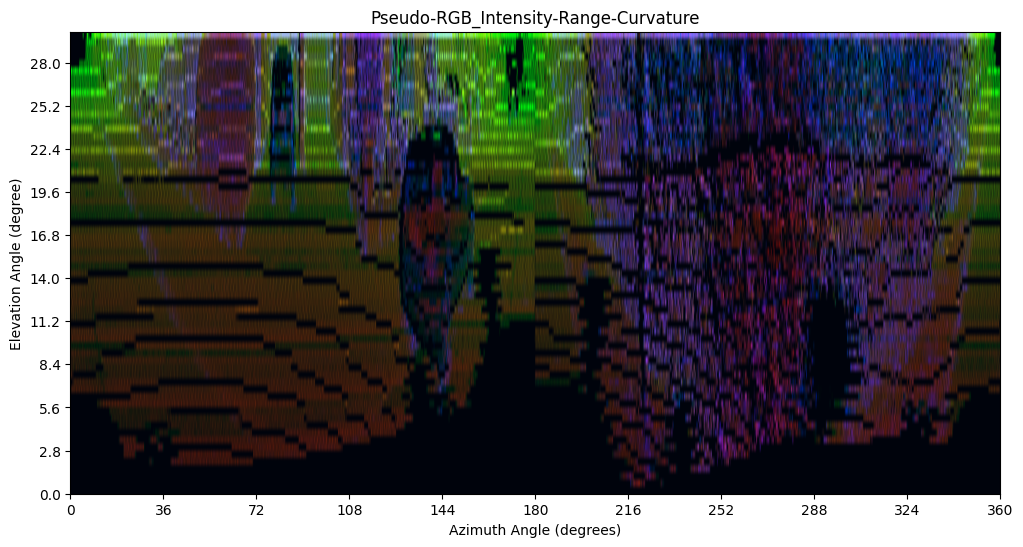

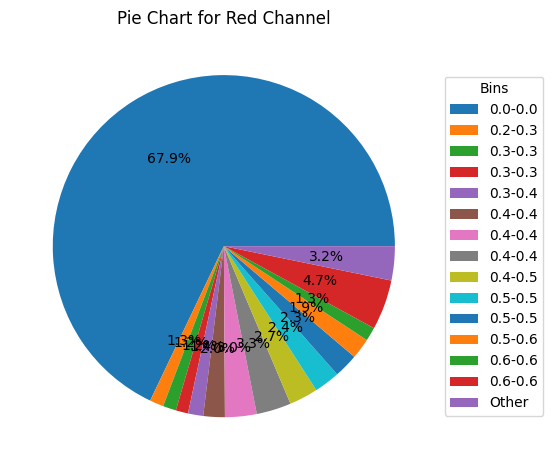

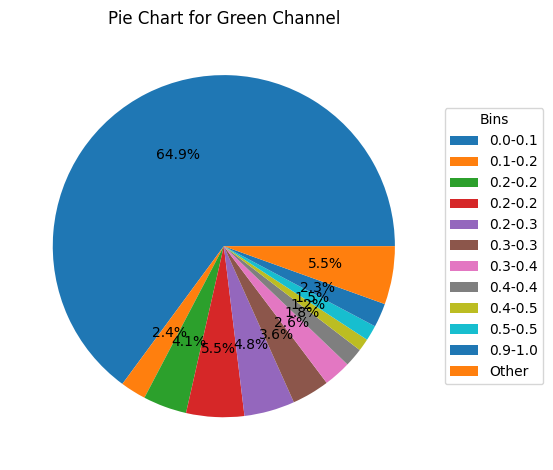

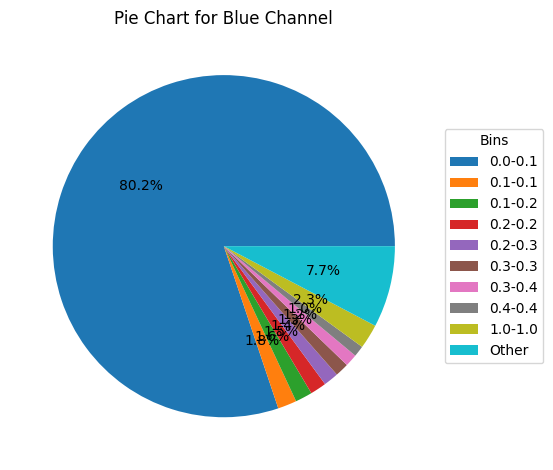

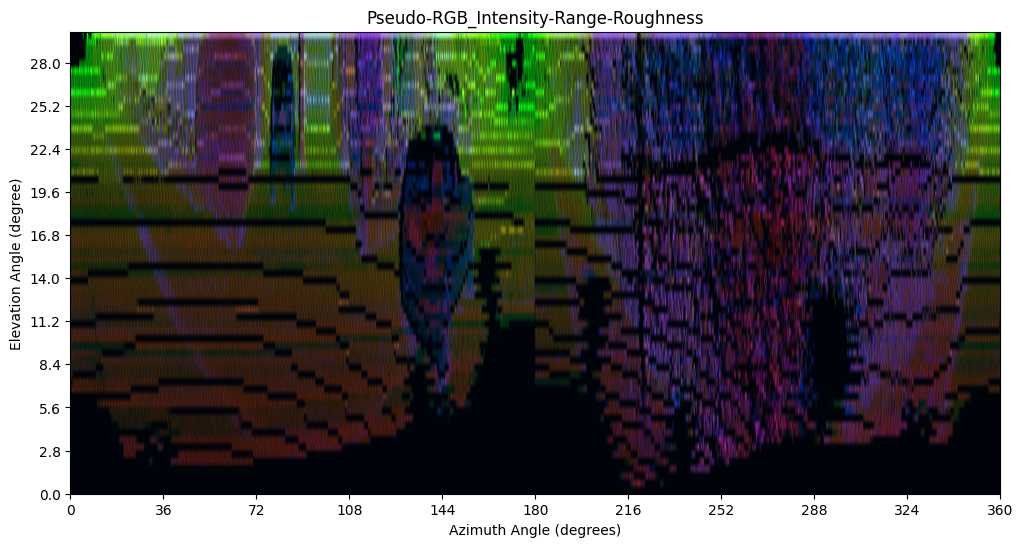

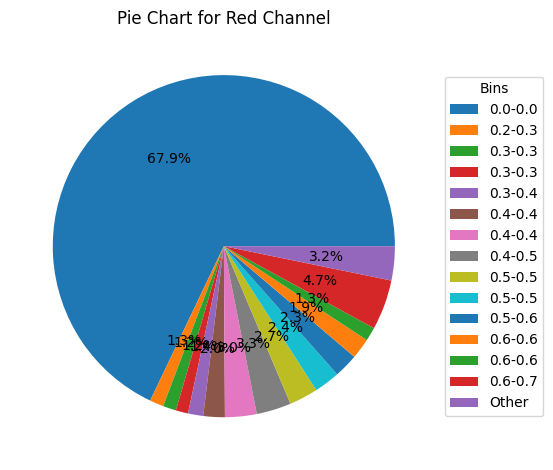

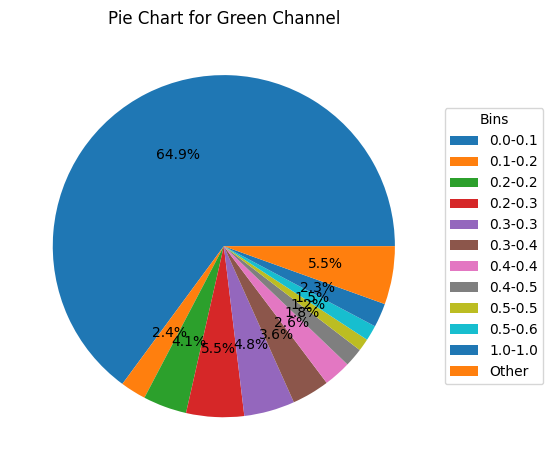

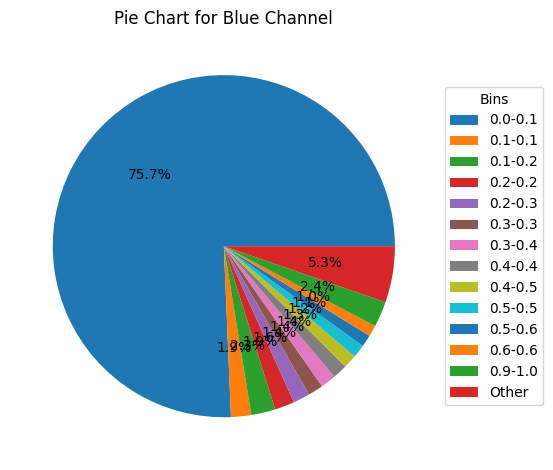

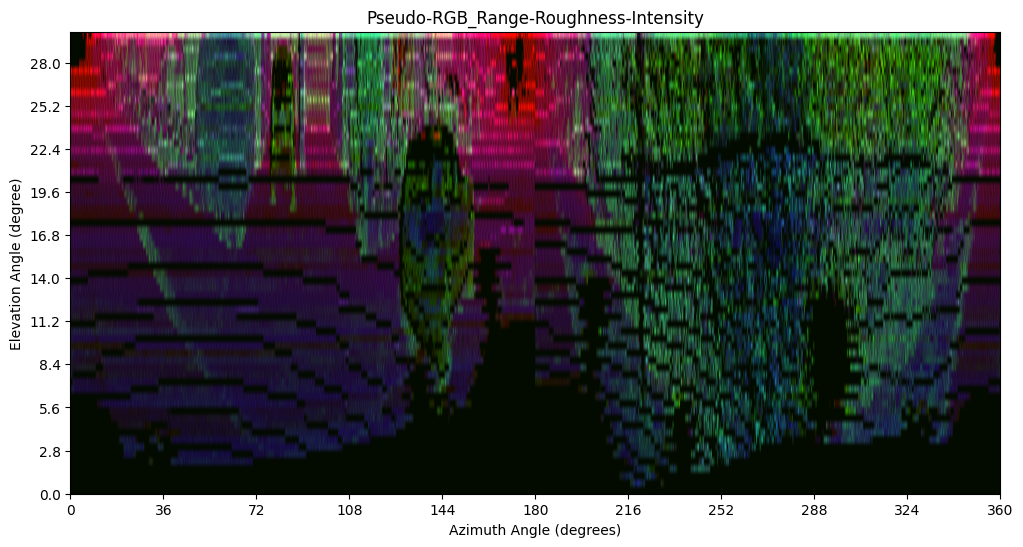

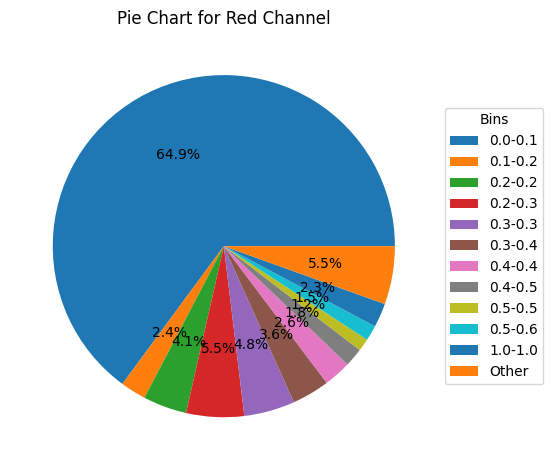

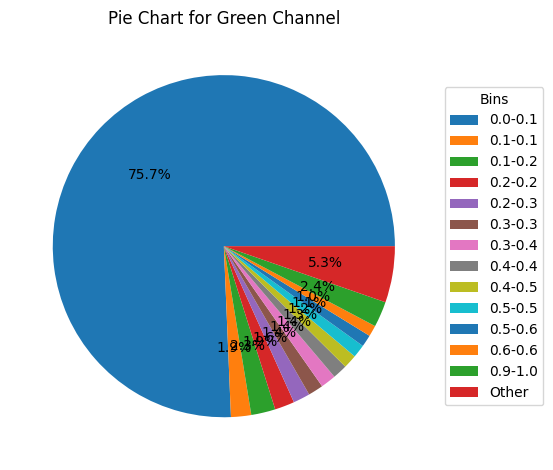

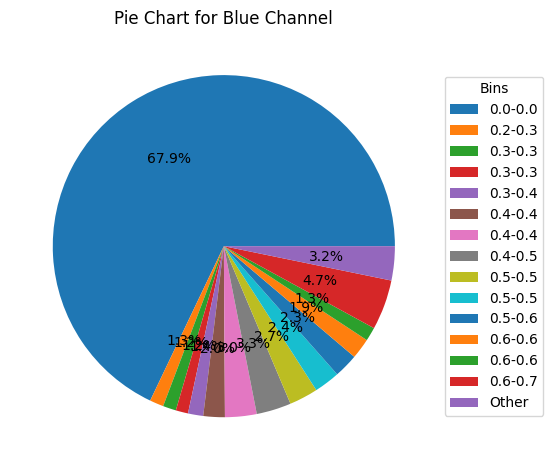

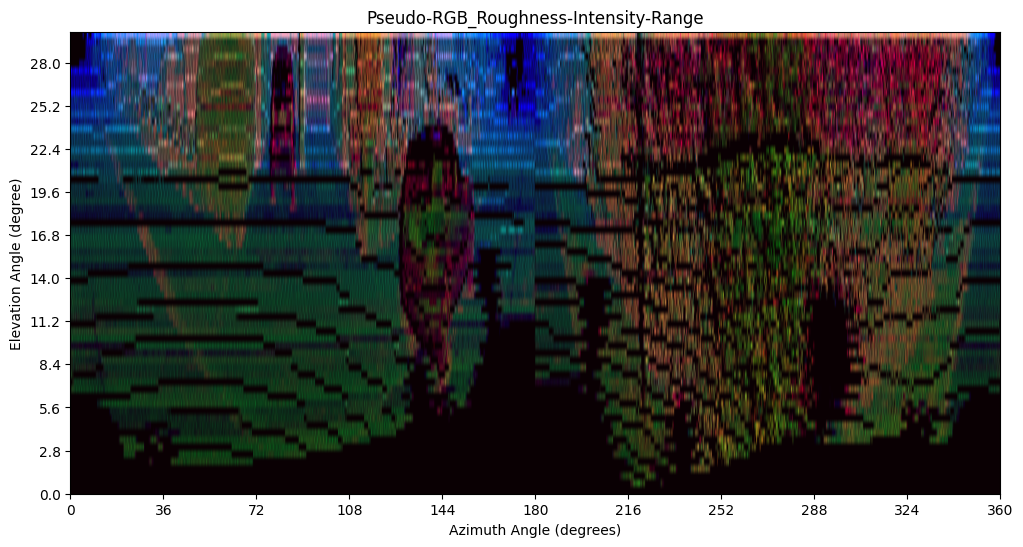

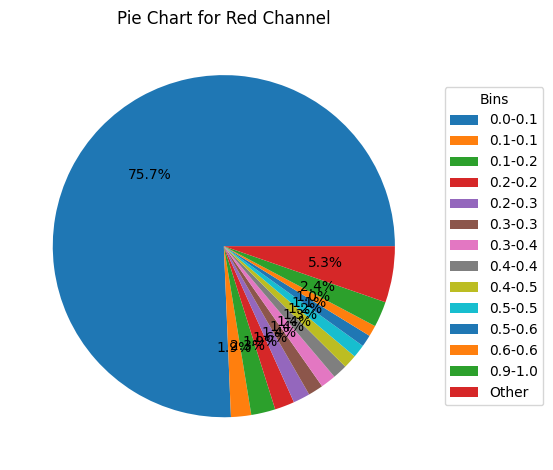

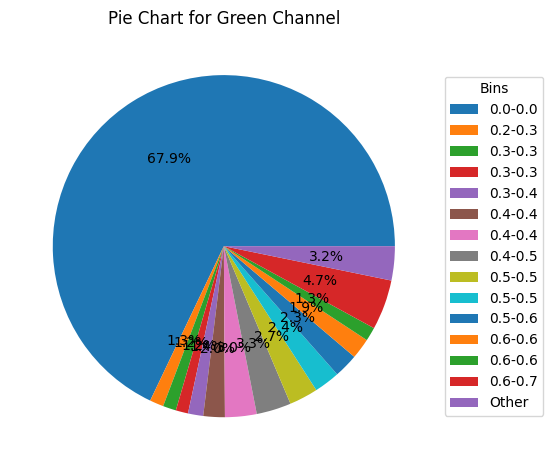

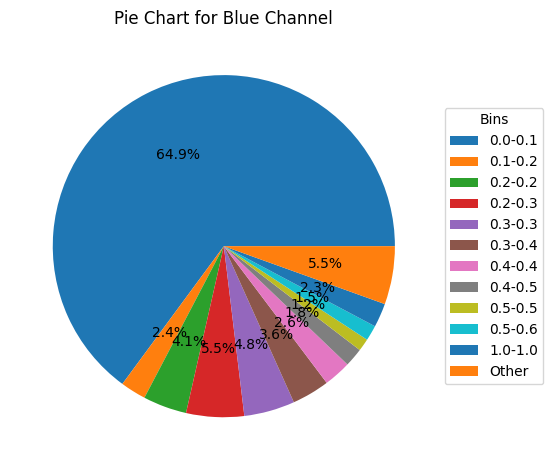

In [17]:

# Create the pseudo-RGB image
figure_title_1 = 'Pseudo-RGB_Intensity-Range-Curvature'
figure_title_2 = 'Pseudo-RGB_Intensity-Range-Roughness'
figure_title_3 = 'Pseudo-RGB_Range-Roughness-Intensity'
figure_title_4 = 'Pseudo-RGB_Roughness-Intensity-Range'

intensity_image_adjusted = output_images_dict['Intensity Map (adjusted)']
range_image_adjusted = output_images_dict['Range Map (adjusted)']
curvature_image_adjusted = output_images_dict['Curvature Map (adjusted)']
roughness_image_adjusted = output_images_dict['Roughness Map (adjusted)']
pseudo_rgb_image_1 = create_pseudo_rgb_image(intensity_image_adjusted, range_image_adjusted, curvature_image_adjusted, figure_title_1, saveflag=saveflag)
pseudo_rgb_image_2 = create_pseudo_rgb_image(intensity_image_adjusted, range_image_adjusted, roughness_image_adjusted, figure_title_2, saveflag=saveflag)
pseudo_rgb_image_3 = create_pseudo_rgb_image(range_image_adjusted, roughness_image_adjusted, intensity_image_adjusted, figure_title_3, saveflag=saveflag)
pseudo_rgb_image_4 = create_pseudo_rgb_image(roughness_image_adjusted, intensity_image_adjusted, range_image_adjusted, figure_title_4, saveflag=saveflag)


## Notes
- The spherical projection from the SemanticKITTI need to be improved. Possibly the parameters such as vertical fov and angular resolution was not correctly set.
- Need to check out the code in semantic-kitti-api
- Scripts for running a visualizer api, go to terminal and run the following commands:
```bash
conda activate semantic_kitti_env
cd ~mylab/semantic-kitti-api
./visualize.py --sequence 00 --dataset /home/fzhcis/mylab/mmdetection3d/data/semantickitti
```